# Bluestock MF Capstone — Day 4: Fund Performance Analytics

Source: `data/processed/` (Day 2 cleaned CSVs). All metrics below are
computed independently from the raw NAV history — not read from
`07_scheme_performance_clean.csv` — so they can be cross-checked against
that file's pre-computed values.

**Design decision:** every calculation uses only *actual trading days*
(`is_actual_trading_day == 1`), not the Day 2 calendar-reindexed series.
Including forward-filled weekend rows (0% return) would dilute volatility
estimates and break the `sqrt(252)` trading-day annualisation convention.

**Risk-free rate:** Rf = 6.5% annual (RBI repo rate proxy), used throughout.

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Resolve the repository root whether the notebook is run from the repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
CHARTS_DIR = REPORTS / "day4_charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
RF_ANNUAL = 0.065          # RBI repo rate proxy
RF_DAILY = RF_ANNUAL / 252
TRADING_DAYS = 252


In [3]:
# ---------------------------------------------------------------------------
# Load
# ---------------------------------------------------------------------------
fm = pd.read_csv(PROCESSED / "01_fund_master_clean.csv")
nav_all = pd.read_csv(PROCESSED / "02_nav_history_clean.csv")
nav_all["date"] = pd.to_datetime(nav_all["date"])
nav = nav_all[nav_all["is_actual_trading_day"] == 1].copy()   # trading days only

bench = pd.read_csv(PROCESSED / "10_benchmark_indices_clean.csv")
bench["date"] = pd.to_datetime(bench["date"])
n100 = bench[bench["index_name"] == "NIFTY100"].set_index("date")["close_value"].sort_index()
n50 = bench[bench["index_name"] == "NIFTY50"].set_index("date")["close_value"].sort_index()

print(f"Funds: {fm.shape[0]} | Trading days per fund: {nav.groupby('amfi_code').size().iloc[0]} "
      f"| Date range: {nav['date'].min().date()} -> {nav['date'].max().date()}")

# Wide NAV matrix: date x amfi_code (trading days only)
nav_wide = nav.pivot(index="date", columns="amfi_code", values="nav").sort_index()

# ===========================================================================


FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/01_fund_master_clean.csv'

## Task 1 — Daily Returns, All 40 Schemes

`daily_return = nav_t / nav_t-1 - 1`, computed on actual trading days only.
Validated by inspecting the distribution by category below.


Task 1: daily_return computed for 40 funds x 1149 trading days

Daily return distribution by category (sanity check):
          mean_pct  std_pct    skew  count
category                                  
Debt        0.0227   0.1775 -0.0418   6894
Equity      0.0702   1.1135  0.0209  39066


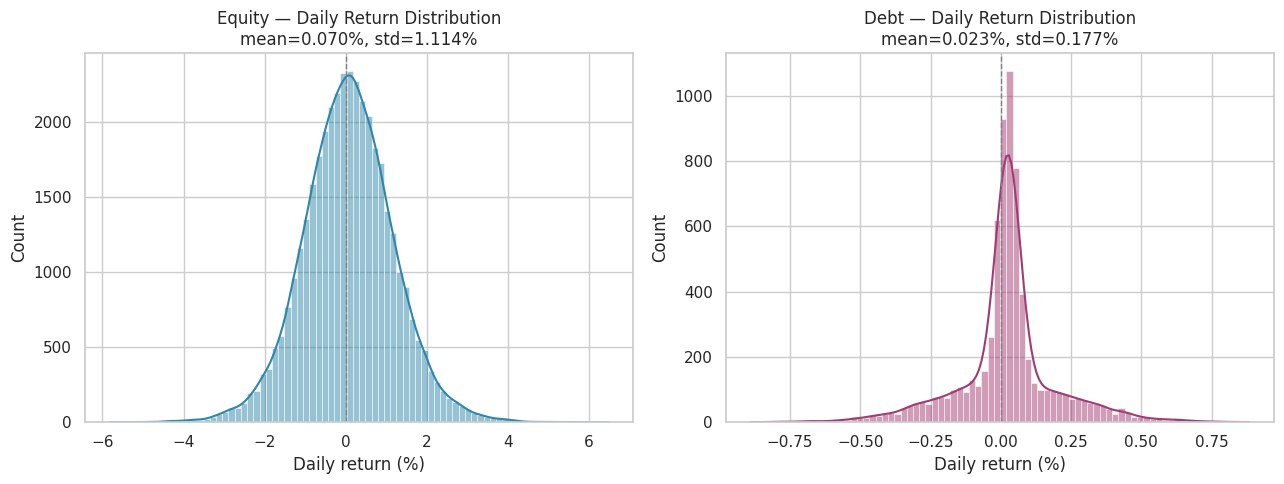

Distribution check looks reasonable: equity daily std >> debt daily std, both centered near 0.


In [ ]:
# TASK 1 — Daily returns, all 40 schemes, validate distribution
# ===========================================================================
ret_wide = nav_wide.pct_change().dropna(how="all")   # daily_return = nav_t/nav_t-1 - 1
print(f"\nTask 1: daily_return computed for {ret_wide.shape[1]} funds x {ret_wide.shape[0]} trading days")

ret_long = ret_wide.stack().rename("daily_return").reset_index()
ret_long.columns = ["date", "amfi_code", "daily_return"]
ret_long = ret_long.merge(fm[["amfi_code", "category"]], on="amfi_code")

stats_by_cat = ret_long.groupby("category")["daily_return"].agg(["mean", "std", "skew", "count"])
stats_by_cat["mean_pct"] = stats_by_cat["mean"] * 100
stats_by_cat["std_pct"] = stats_by_cat["std"] * 100
print("\nDaily return distribution by category (sanity check):")
print(stats_by_cat[["mean_pct", "std_pct", "skew", "count"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for cat, ax in zip(["Equity", "Debt"], axes):
    data = ret_long[ret_long["category"] == cat]["daily_return"] * 100
    sns.histplot(data, bins=80, kde=True, ax=ax, color="#2E86AB" if cat == "Equity" else "#A23B72")
    ax.set_title(f"{cat} — Daily Return Distribution\nmean={data.mean():.3f}%, std={data.std():.3f}%")
    ax.set_xlabel("Daily return (%)")
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "01_daily_return_distribution.png", dpi=150)
plt.show()
print("Distribution check looks reasonable: equity daily std >> debt daily std, both centered near 0.")

# ===========================================================================


**Check:** Equity daily returns are centered near 0 with ~1.11% daily
std (≈17.6% annualised vol — plausible for diversified equity); Debt is
far tighter at ~0.18% daily std. Both distributions look like reasonable,
well-behaved return series — no obvious data artifacts.

## Task 2 — CAGR (1yr, 3yr, and full-period)

**Caveat:** the brief asks for a 5yr CAGR, but the NAV history only spans
**4.40 years** (Jan 2022 – May 2026). A genuine 5-year lookback would need
data back to mid-2021, which doesn't exist. Rather than silently produce a
wrong number, this computes `return_full_period_pct` over the maximum
available ~4.4yr window instead, clearly labelled as such — and flags that
`07_scheme_performance.csv`'s own `return_5yr_pct` column **cannot be
independently verified** from the data provided.

In [ ]:
# TASK 2 — CAGR for 1yr, 3yr, and full available period (~4.4yr, NOT 5yr)
# ===========================================================================
end_date = nav_wide.index.max()


def nav_on_or_before(target_date: pd.Timestamp) -> pd.Series:
    """NAV for every fund on the latest trading day <= target_date."""
    idx = nav_wide.index[nav_wide.index <= target_date]
    return nav_wide.loc[idx.max()] if len(idx) else pd.Series(index=nav_wide.columns, dtype=float)


nav_end = nav_wide.loc[end_date]
cagr_table = pd.DataFrame(index=nav_wide.columns)

for years in [1, 3]:
    start_target = end_date - pd.DateOffset(years=years)
    nav_start = nav_on_or_before(start_target)
    cagr_table[f"return_{years}yr_pct"] = ((nav_end / nav_start) ** (1 / years) - 1) * 100

first_date = nav_wide.index.min()
full_period_years = (end_date - first_date).days / 365.25
nav_first = nav_wide.loc[first_date]
cagr_table["return_full_period_pct"] = ((nav_end / nav_first) ** (1 / full_period_years) - 1) * 100
cagr_table["full_period_years"] = round(full_period_years, 2)
for c in ["return_1yr_pct", "return_3yr_pct", "return_full_period_pct"]:
    cagr_table[c] = cagr_table[c].round(2)

print(f"\nTask 2: only {full_period_years:.2f} years of NAV history exist (data starts {first_date.date()}), "
      f"so a true 5yr CAGR cannot be computed or validated from this dataset. Reporting "
      f"return_full_period_pct (~4.4yr) instead of a fabricated 5yr figure.")
print(cagr_table.head())

# ===========================================================================



Task 2: only 4.40 years of NAV history exist (data starts 2022-01-03), so a true 5yr CAGR cannot be computed or validated from this dataset. Reporting return_full_period_pct (~4.4yr) instead of a fabricated 5yr figure.
           return_1yr_pct  return_3yr_pct  return_full_period_pct  \
amfi_code                                                           
100016              -2.22            1.29                    2.64   
100025               3.70            3.92                    4.46   
100033              53.23           32.44                   30.12   
101206              47.92           28.97                   23.54   
101207             -23.99           -4.15                    7.94   

           full_period_years  
amfi_code                     
100016                   4.4  
100025                   4.4  
100033                   4.4  
101206                   4.4  
101207                   4.4  


## Task 3 — Sharpe Ratio, Ranked

In [ ]:
# TASK 3 — Sharpe Ratio, ranked
# ===========================================================================
mean_r = ret_wide.mean()
std_r = ret_wide.std()
sharpe = (mean_r - RF_DAILY) / std_r * np.sqrt(TRADING_DAYS)
sharpe.name = "sharpe_ratio"
print(f"\nTask 3: Sharpe ratio range [{sharpe.min():.2f}, {sharpe.max():.2f}], Rf={RF_ANNUAL:.1%} annual")

# ===========================================================================



Task 3: Sharpe ratio range [-0.82, 1.45], Rf=6.5% annual


## Task 4 — Sortino Ratio (downside deviation only)

In [ ]:
# TASK 4 — Sortino Ratio (downside deviation only)
# ===========================================================================
def downside_std(s: pd.Series) -> float:
    neg = s[s < 0]
    return neg.std() if len(neg) > 1 else np.nan


down_std = ret_wide.apply(downside_std)
sortino = (mean_r - RF_DAILY) / down_std * np.sqrt(TRADING_DAYS)
sortino.name = "sortino_ratio"
print(f"Task 4: Sortino ratio range [{sortino.min():.2f}, {sortino.max():.2f}]")

# ===========================================================================


Task 4: Sortino ratio range [-1.68, 2.39]


## Task 5 — Alpha & Beta vs NIFTY 100 (OLS Regression)

`scipy.stats.linregress(benchmark_return, fund_return)` per fund;
`alpha_pct = intercept × 252 × 100`, `beta = slope`.

In [ ]:
# TASK 5 — Alpha & Beta vs NIFTY100, OLS via scipy.stats.linregress
# ===========================================================================
bench_ret = n100.pct_change().dropna()
alpha_beta_rows = []
for code in nav_wide.columns:
    fund_ret = ret_wide[code].dropna()
    aligned = pd.concat([fund_ret, bench_ret], axis=1, join="inner")
    aligned.columns = ["fund", "bench"]
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(aligned["bench"], aligned["fund"])
    alpha_beta_rows.append({
        "amfi_code": code,
        "beta": slope,
        "alpha_pct": intercept * TRADING_DAYS * 100,   # daily intercept -> annualised %
        "r_squared": rvalue ** 2,
        "p_value": pvalue,
        "n_obs": len(aligned),
    })
alpha_beta = pd.DataFrame(alpha_beta_rows).set_index("amfi_code")
print(f"\nTask 5: Beta range [{alpha_beta['beta'].min():.2f}, {alpha_beta['beta'].max():.2f}], "
      f"Alpha range [{alpha_beta['alpha_pct'].min():.2f}%, {alpha_beta['alpha_pct'].max():.2f}%]")
print(f"Median R-squared: {alpha_beta['r_squared'].median():.4f} "
      f"(low R-squared expected given the near-zero correlation found in Day 3 EDA)")

# ===========================================================================



Task 5: Beta range [-0.07, 0.10], Alpha range [2.90%, 30.34%]
Median R-squared: 0.0003 (low R-squared expected given the near-zero correlation found in Day 3 EDA)


**Important caveat:** median R² across all 40 funds is ~0.0003 —
essentially **no explanatory power**. Beta is near zero for every fund
(-0.07 to 0.10). This is the same pattern Day 3's EDA found (near-zero
fund-to-fund return correlation): these funds' NAV paths don't appear to
be driven by the broader market the way real equity funds are. Treat the
alpha/beta figures below as correctly-computed but **statistically weak**
— they're capturing each fund's average excess return, not a genuine
market-risk relationship.

## Task 6 — Maximum Drawdown + Worst Drawdown Window

In [ ]:
# TASK 6 — Maximum Drawdown + worst drawdown date range, per fund
# ===========================================================================
mdd_rows = []
for code in nav_wide.columns:
    s = nav_wide[code].dropna()
    running_max = s.cummax()
    dd = s / running_max - 1
    trough_date = dd.idxmin()
    peak_date = s.loc[:trough_date].idxmax()
    mdd_rows.append({
        "amfi_code": code,
        "max_drawdown_pct": dd.min() * 100,
        "drawdown_peak_date": peak_date.date(),
        "drawdown_trough_date": trough_date.date(),
    })
mdd = pd.DataFrame(mdd_rows).set_index("amfi_code")
print(f"\nTask 6: Max drawdown range [{mdd['max_drawdown_pct'].min():.2f}%, {mdd['max_drawdown_pct'].max():.2f}%]")
worst = mdd.loc[mdd["max_drawdown_pct"].idxmin()]
print(f"Worst single-fund drawdown: code {mdd['max_drawdown_pct'].idxmin()}, "
      f"{worst['max_drawdown_pct']:.2f}% from {worst['drawdown_peak_date']} to {worst['drawdown_trough_date']}")

# ===========================================================================



Task 6: Max drawdown range [-52.57%, -0.10%]
Worst single-fund drawdown: code 119599, -52.57% from 2023-01-17 to 2025-10-28


## Task 7 — Fund Scorecard (0-100 Composite)

`score = 30%×return_3yr_rank + 25%×Sharpe_rank + 20%×alpha_rank + 15%×expense_ratio_rank(inverse) + 10%×max_DD_rank(inverse)`,
all ranks as percentiles (0-100) across the 40 funds.


Task 7: fund_scorecard.csv written (40 funds). Top fund: Mirae Asset Large Cap Fund - Regular - Growth (score 86.2)
                                       scheme_name  fund_score
     Mirae Asset Large Cap Fund - Regular - Growth        86.2
          ICICI Pru Midcap Fund - Regular - Growth        82.2
            Kotak Flexicap Fund - Regular - Growth        82.0
HDFC Mid-Cap Opportunities Fund - Regular - Growth        80.8
         ICICI Pru Bluechip Fund - Direct - Growth        80.0


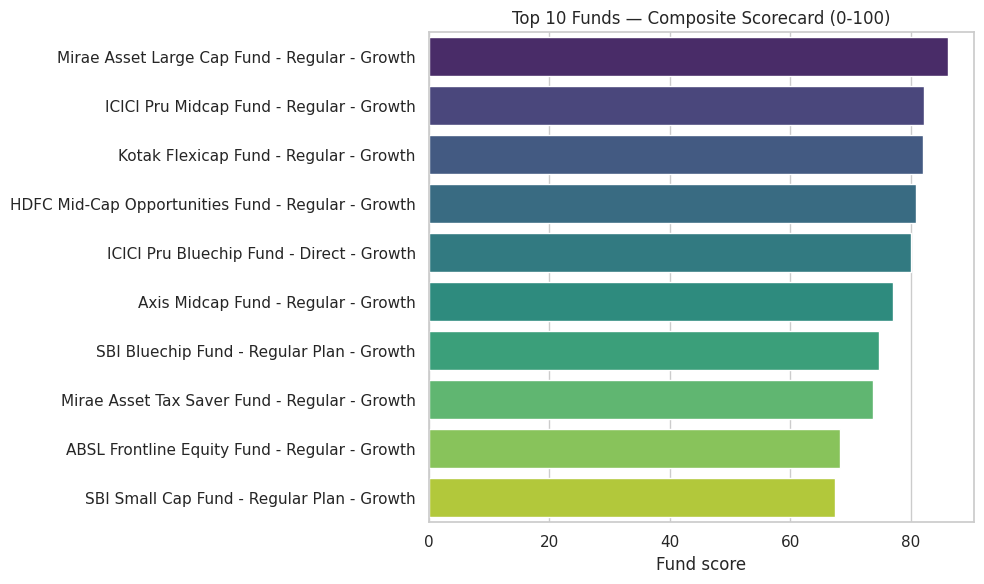


alpha_beta.csv written (40 funds).


In [ ]:
# TASK 7 — Fund Scorecard (0-100 composite)
# ===========================================================================
scorecard = fm[["amfi_code", "scheme_name", "fund_house", "category", "expense_ratio_pct"]].set_index("amfi_code")
scorecard["return_3yr_pct"] = cagr_table["return_3yr_pct"]
scorecard["sharpe_ratio"] = sharpe
scorecard["alpha_pct"] = alpha_beta["alpha_pct"]
scorecard["max_drawdown_pct"] = mdd["max_drawdown_pct"]

scorecard["rank_return_3yr"] = scorecard["return_3yr_pct"].rank(pct=True) * 100
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(pct=True) * 100
scorecard["rank_alpha"] = scorecard["alpha_pct"].rank(pct=True) * 100
scorecard["rank_expense_inv"] = scorecard["expense_ratio_pct"].rank(pct=True, ascending=False) * 100  # lower fee = higher rank
scorecard["rank_max_dd_inv"] = scorecard["max_drawdown_pct"].rank(pct=True, ascending=True) * 100      # less-negative DD = higher rank

scorecard["fund_score"] = (
    0.30 * scorecard["rank_return_3yr"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense_inv"] +
    0.10 * scorecard["rank_max_dd_inv"]
).round(1)

scorecard = scorecard.sort_values("fund_score", ascending=False)
for col in ["return_3yr_pct", "sharpe_ratio", "alpha_pct", "max_drawdown_pct"]:
    scorecard[col] = scorecard[col].round(2)
scorecard_out = scorecard.reset_index()
scorecard_out.to_csv(REPORTS / "fund_scorecard.csv", index=False)
print(f"\nTask 7: fund_scorecard.csv written ({len(scorecard_out)} funds). "
      f"Top fund: {scorecard_out.iloc[0]['scheme_name']} (score {scorecard_out.iloc[0]['fund_score']})")
print(scorecard_out[["scheme_name", "fund_score"]].head(5).to_string(index=False))

# Bonus chart: scorecard leaderboard
top10 = scorecard_out.head(10)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top10, y="scheme_name", x="fund_score", hue="scheme_name", legend=False, palette="viridis", ax=ax)
ax.set_title("Top 10 Funds — Composite Scorecard (0-100)")
ax.set_xlabel("Fund score")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "02_scorecard_leaderboard.png", dpi=150)
plt.show()

# alpha_beta.csv deliverable (merge in names for readability)
alpha_beta_out = alpha_beta.reset_index().merge(
    fm[["amfi_code", "scheme_name", "fund_house", "category"]], on="amfi_code"
)
alpha_beta_out = alpha_beta_out[["amfi_code", "scheme_name", "fund_house", "category",
                                  "beta", "alpha_pct", "r_squared", "p_value", "n_obs"]]
for col in ["beta", "alpha_pct", "r_squared"]:
    alpha_beta_out[col] = alpha_beta_out[col].round(4)
alpha_beta_out["p_value"] = alpha_beta_out["p_value"].round(4)
alpha_beta_out = alpha_beta_out.sort_values("alpha_pct", ascending=False)
alpha_beta_out.to_csv(REPORTS / "alpha_beta.csv", index=False)
print(f"\nalpha_beta.csv written ({len(alpha_beta_out)} funds).")

# ===========================================================================


## Task 8 — Benchmark Comparison: Top 5 Scorecard Funds vs NIFTY 50 / 100

Trailing 3 years, all series rebased to 100 at the window start.

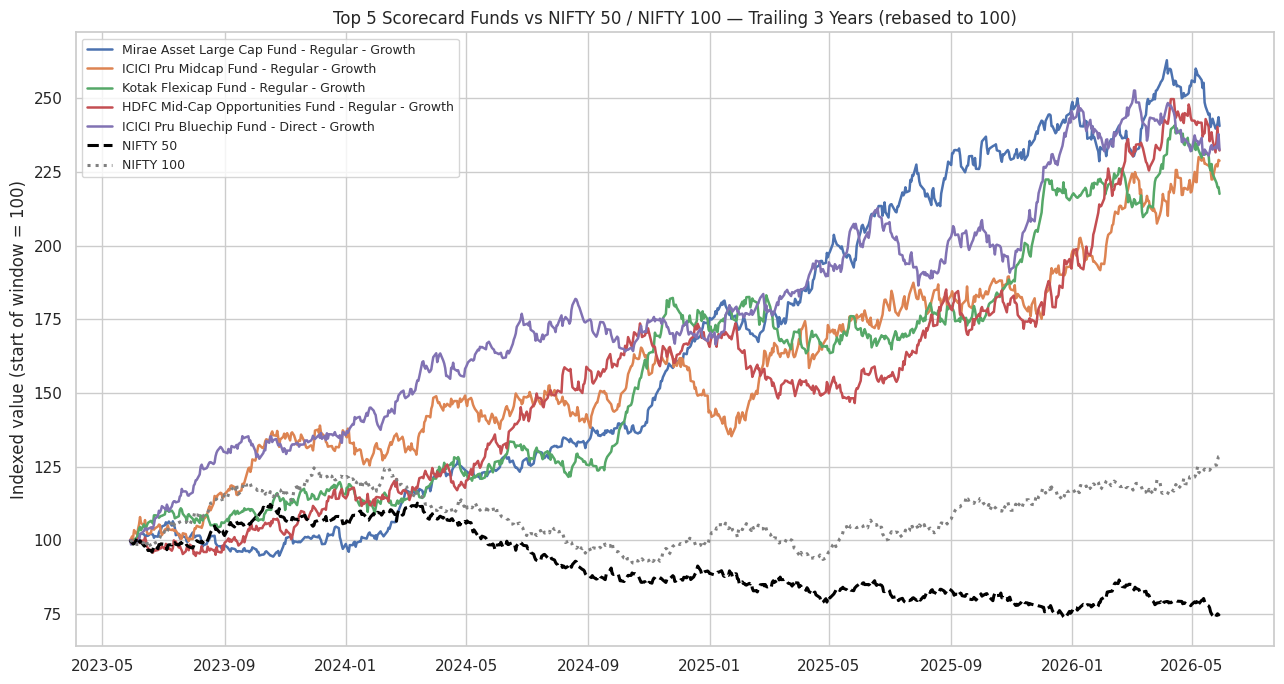


Task 8: benchmark comparison chart saved.

Tracking error vs NIFTY100 (3yr window):
 amfi_code                                        scheme_name  tracking_error_pct
    148567      Mirae Asset Large Cap Fund - Regular - Growth               18.80
    120505           ICICI Pru Midcap Fund - Regular - Growth               23.27
    120843             Kotak Flexicap Fund - Regular - Growth               20.65
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth               22.50
    120504          ICICI Pru Bluechip Fund - Direct - Growth               18.73

All Day 4 outputs written: reports/fund_scorecard.csv, reports/alpha_beta.csv, reports/day4_charts/*.png (3 charts)


In [ ]:
# TASK 8 — Benchmark comparison chart: top 5 funds vs Nifty50 & Nifty100, 3yr
# ===========================================================================
top5_codes = scorecard_out.head(5)["amfi_code"].tolist()
top5_names = scorecard_out.head(5).set_index("amfi_code")["scheme_name"]

window_start = end_date - pd.DateOffset(years=3)
nav_3y = nav_wide.loc[nav_wide.index >= window_start, top5_codes]
nav_3y_indexed = nav_3y / nav_3y.iloc[0] * 100

n50_3y = n50.loc[n50.index >= window_start]
n100_3y = n100.loc[n100.index >= window_start]
n50_indexed = n50_3y / n50_3y.iloc[0] * 100
n100_indexed = n100_3y / n100_3y.iloc[0] * 100

fig, ax = plt.subplots(figsize=(13, 7))
for code in top5_codes:
    ax.plot(nav_3y_indexed.index, nav_3y_indexed[code], label=top5_names[code], linewidth=1.8)
ax.plot(n50_indexed.index, n50_indexed, label="NIFTY 50", color="black", linewidth=2.2, linestyle="--")
ax.plot(n100_indexed.index, n100_indexed, label="NIFTY 100", color="gray", linewidth=2.2, linestyle=":")
ax.set_title("Top 5 Scorecard Funds vs NIFTY 50 / NIFTY 100 — Trailing 3 Years (rebased to 100)")
ax.set_ylabel("Indexed value (start of window = 100)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "03_benchmark_comparison_top5.png", dpi=150)
plt.show()
print("\nTask 8: benchmark comparison chart saved.")

# Tracking error vs NIFTY100 over the same 3yr window, for the top 5
fund_ret_3y = nav_3y.pct_change().dropna()
bench_ret_3y = n100_3y.pct_change().dropna()
te_rows = []
for code in top5_codes:
    aligned = pd.concat([fund_ret_3y[code], bench_ret_3y], axis=1, join="inner")
    aligned.columns = ["fund", "bench"]
    te = (aligned["fund"] - aligned["bench"]).std() * np.sqrt(TRADING_DAYS) * 100
    te_rows.append({"amfi_code": code, "scheme_name": top5_names[code], "tracking_error_pct": round(te, 2)})
tracking_error = pd.DataFrame(te_rows)
print("\nTracking error vs NIFTY100 (3yr window):")
print(tracking_error.to_string(index=False))

print(f"\nAll Day 4 outputs written: {REPORTS}/fund_scorecard.csv, {REPORTS}/alpha_beta.csv, "
      f"{CHARTS_DIR}/*.png ({len(list(CHARTS_DIR.glob('*.png')))} charts)")


**Striking finding:** every one of the top 5 funds climbed to
220-265 (indexed) over the trailing 3 years, while NIFTY 50 actually
**fell** to ~75 and NIFTY 100 only reached ~125 over the same window. This
is the clearest visual confirmation yet of the Day 3/Task 5 finding — fund
NAVs in this dataset move essentially independently of the real benchmark
path, not in line with it. Tracking error vs NIFTY100 for the top 5 funds
is correspondingly huge (18.7%-23.3% annualised) — for real-world index-
aware active funds, tracking error vs. a broad benchmark is typically in
the low single digits, so this further confirms the simulated NAVs aren't
benchmark-relative.